# 📘 Notebook 8: Future Directions, Modern LLM Stack & Roadmap
## Building LLMs from Scratch Workshop - Capstone

> **"Knowing how to build an LLM from scratch is 10%. Knowing where the field is going and how to ship real products is the other 90%."**

---

### What We've Built So Far (Notebooks 1-7)

| Stage | What We Did | Notebook |
|-------|-------------|----------|
| Tokenization | BPE from scratch, sliding windows | NB 1 |
| Attention | Self-attention → Multi-head → Causal masking | NB 2 |
| Architecture | Full GPT model (embeddings, FFN, LayerNorm) | NB 3 |
| Pretraining | Next-token prediction, LR scheduling | NB 4 |
| SFT | Instruction tuning with loss masking | NB 5 |
| RLHF | Reward model (Bradley-Terry) + PPO | NB 6 |
| Chat Model | 3-model comparison, interactive chat | NB 7 |

**This notebook bridges the gap** between what we built (mini-GPT) and what the real industry uses (billion-parameter systems, RAG, agents, deployment at scale).

---

### What This Notebook Covers

1. **Why basic pipeline isn't enough** - real-world limitations
2. **Modern techniques (2023-2025)** - LoRA, RAG, Agents, Multimodal
3. **Evaluation & Benchmarking** - how to measure LLM quality
4. **Deployment & Scaling** - quantization, serving, cost
5. **Research directions** - where the field is heading
6. **Learning roadmap** - your path from beginner to builder
7. **Resources** - papers, codebases, datasets, books
8. **Mini practicals** - LoRA, RAG, and Agent code demos

---


---
# Section 1: Why the Basic LLM Pipeline Is Not Enough

Our 7-notebook pipeline taught the **foundational mechanics** - but production LLMs face problems that vanilla GPT + SFT + RLHF cannot solve alone.

---

## 1.1 Limitations of Vanilla GPT Pretraining

| Problem | Why It Happens | Impact |
|---------|---------------|--------|
| **Hallucination** | Model generates plausible-sounding but factually wrong text | Users can't trust outputs for factual tasks |
| **Knowledge cutoff** | Model only knows what was in training data | Can't answer about recent events |
| **No grounding** | Model has no access to real databases, APIs, or documents | Can't look up facts or verify claims |
| **Cost scaling** | Training from scratch costs millions of dollars | Only a handful of labs can afford it |
| **Data inefficiency** | Needs trillions of tokens to learn basic facts | Most compute is "wasted" on redundant patterns |

## 1.2 Limitations of SFT

- **Garbage in, garbage out** - SFT quality is entirely dependent on instruction data quality
- **Catastrophic forgetting** - fine-tuning can destroy useful pretrained knowledge
- **Sycophancy** - SFT models learn to agree with users rather than be truthful
- **No self-correction** - model can't verify or fix its own mistakes

## 1.3 Limitations of RLHF

- **Reward hacking** - the policy learns to exploit the reward model rather than genuinely improve
- **Human disagreement** - annotators disagree on what "good" means, especially for subjective tasks
- **Expensive** - requires human annotators, reward model training, and PPO (3 models in memory)
- **KL collapse** - if KL penalty is too low, model degenerates; too high, it doesn't learn

## 1.4 The Real-World Gap

```
What we built:          What production needs:
───────────────         ─────────────────────
~5M parameters          7B-700B parameters
Synthetic data          Trillions of tokens
CPU training            Thousands of GPUs
Single turn             Multi-turn conversations
English text            Multilingual + multimodal
No tool use             API calls, search, code execution
No memory               Persistent context across sessions
```

**The rest of this notebook shows how the industry bridges this gap.**


In [1]:
# Quick illustration: Why hallucination is hard to fix with just SFT/RLHF

# The fundamental problem: LLMs are pattern completers, not knowledge databases
# They predict the MOST LIKELY next token - not the MOST TRUE next token

import torch
import torch.nn.functional as F

# Simulated logits for "The capital of Australia is ___"
# Even a well-trained model assigns probability mass to wrong answers
simulated_logits = {
    "Canberra": 0.45,    # Correct
    "Sydney": 0.35,      # Common wrong answer (most populated city)
    "Melbourne": 0.12,   # Another wrong answer
    "Brisbane": 0.05,
    "Perth": 0.03,
}

print("Simulated token probabilities for 'The capital of Australia is ___'")
print("=" * 55)
for city, prob in simulated_logits.items():
    bar = "█" * int(prob * 50)
    correct = " ✓" if city == "Canberra" else ""
    print(f"  {city:12s}  {prob:.0%}  {bar}{correct}")

print()
print("Even with 45% on the correct answer, the model will")
print("sometimes hallucinate 'Sydney' - and it SOUNDS confident!")
print()
print("Solutions explored later in this notebook:")
print("  → RAG (retrieve facts before generating)")
print("  → Tool use (call a search API)")
print("  → Self-consistency (generate multiple, vote)")


Simulated token probabilities for 'The capital of Australia is ___'
  Canberra      45%  ██████████████████████ ✓
  Sydney        35%  █████████████████
  Melbourne     12%  ██████
  Brisbane      5%  ██
  Perth         3%  █

Even with 45% on the correct answer, the model will
sometimes hallucinate 'Sydney' - and it SOUNDS confident!

Solutions explored later in this notebook:
  → RAG (retrieve facts before generating)
  → Tool use (call a search API)
  → Self-consistency (generate multiple, vote)


---
# Section 2: Modern LLM Techniques (2023-2025)

This section covers the five most impactful advances since GPT-3/ChatGPT.

---

## 2.1 Parameter-Efficient Fine-Tuning (PEFT)

### The Problem
Full fine-tuning updates **all** model parameters. For a 7B model, that's 7 billion floats - requiring 50+ GB of GPU memory just for gradients and optimizer states.

### The Solution: LoRA (Low-Rank Adaptation)

**Key insight:** The weight updates during fine-tuning have **low intrinsic rank**. Instead of updating the full weight matrix W (d × d), we decompose the update into two small matrices:

```
Original:  W_new = W_old + ΔW           (d × d parameters)
LoRA:      W_new = W_old + B × A         (d × r + r × d parameters, r << d)
```

Where `r` (rank) is typically 4-64, so we train **< 1%** of the original parameters.

### LoRA vs QLoRA vs Adapters

| Method | How It Works | Memory Savings | When to Use |
|--------|-------------|----------------|-------------|
| **LoRA** | Low-rank matrices added to attention weights | ~10× less | Most fine-tuning tasks |
| **QLoRA** | LoRA + 4-bit quantized base model | ~50× less | When GPU memory is very limited |
| **Adapters** | Small bottleneck layers inserted between transformer blocks | ~5-10× less | When you need multiple task-specific models |
| **Full fine-tuning** | Update all parameters | No savings | When you have plenty of compute and data |

### When to Use What

```
Decision Tree:
├── Have 80GB+ GPU and tons of data? → Full fine-tuning
├── Have 24GB GPU? → LoRA (rank 16-64)
├── Have 12GB GPU? → QLoRA (4-bit base + LoRA)
├── Have 8GB GPU? → QLoRA with smaller model
└── Have only CPU? → Use API-based fine-tuning (OpenAI, etc.)
```


In [2]:
# ============================================================
# LoRA Implementation from Scratch
# ============================================================
# This shows the CORE idea - how LoRA modifies a linear layer

import torch
import torch.nn as nn
import torch.nn.functional as F
import math

class LoRALayer(nn.Module):
    '''
    Low-Rank Adaptation layer.
    
    Wraps an existing linear layer and adds a low-rank update:
        output = W_original(x) + (B @ A)(x) * scaling
    
    Only A and B are trained. W_original stays frozen.
    
    Args:
        original_layer: The pretrained nn.Linear layer to adapt
        rank: LoRA rank (typically 4-64)
        alpha: Scaling factor (typically equal to rank)
    '''
    
    def __init__(self, original_layer, rank=8, alpha=8):
        super().__init__()
        self.original = original_layer
        self.rank = rank
        
        in_features = original_layer.in_features
        out_features = original_layer.out_features
        
        # Freeze original weights
        for param in self.original.parameters():
            param.requires_grad = False
        
        # LoRA matrices: A (down-projection) and B (up-projection)
        # A is initialized with random Gaussian, B with zeros
        # This means LoRA starts as identity (no change to original)
        self.lora_A = nn.Parameter(torch.randn(rank, in_features) * 0.01)
        self.lora_B = nn.Parameter(torch.zeros(out_features, rank))
        
        # Scaling factor
        self.scaling = alpha / rank
    
    def forward(self, x):
        # Original output (frozen)
        original_out = self.original(x)
        
        # LoRA output: x @ A^T @ B^T * scaling
        lora_out = F.linear(F.linear(x, self.lora_A), self.lora_B) * self.scaling
        
        return original_out + lora_out

# ============================================================
# Demo: Apply LoRA to a pretrained layer
# ============================================================

# Simulate a pretrained linear layer (e.g., from attention)
pretrained_linear = nn.Linear(256, 256)
original_params = sum(p.numel() for p in pretrained_linear.parameters())

# Wrap it with LoRA
lora_layer = LoRALayer(pretrained_linear, rank=8, alpha=8)

# Count trainable parameters
total_params = sum(p.numel() for p in lora_layer.parameters())
trainable_params = sum(p.numel() for p in lora_layer.parameters() if p.requires_grad)
frozen_params = total_params - trainable_params

print("LoRA Layer Analysis")
print("=" * 50)
print(f"Original layer parameters:   {original_params:>10,}")
print(f"LoRA A matrix (rank×in):     {lora_layer.lora_A.numel():>10,}  (rank={lora_layer.rank})")
print(f"LoRA B matrix (out×rank):    {lora_layer.lora_B.numel():>10,}")
print(f"Total LoRA parameters:       {trainable_params:>10,}")
print(f"Frozen parameters:           {frozen_params:>10,}")
print(f"Compression ratio:           {original_params / trainable_params:>10.1f}×")
print(f"Trainable / Total:           {trainable_params/total_params*100:>9.2f}%")

# Verify it works
x = torch.randn(2, 16, 256)
out = lora_layer(x)
print(f"\nInput:  {x.shape}")
print(f"Output: {out.shape}")
print(f"\nAt initialization, LoRA output ≈ original (B is zeros):")
orig_out = pretrained_linear(x)
diff = (out - orig_out).abs().max().item()
print(f"Max difference: {diff:.6f} (should be ~0)")


LoRA Layer Analysis
Original layer parameters:       65,792
LoRA A matrix (rank×in):          2,048  (rank=8)
LoRA B matrix (out×rank):         2,048
Total LoRA parameters:            4,096
Frozen parameters:               65,792
Compression ratio:                 16.1×
Trainable / Total:                5.86%

Input:  torch.Size([2, 16, 256])
Output: torch.Size([2, 16, 256])

At initialization, LoRA output ≈ original (B is zeros):
Max difference: 0.000000 (should be ~0)


In [3]:
# ============================================================
# How to apply LoRA to an entire GPT model
# ============================================================

def apply_lora_to_model(model, rank=8, alpha=8, target_modules=None):
    '''
    Apply LoRA to specific layers of a model.
    
    In practice, LoRA is applied to attention projection layers:
    - Q, K, V projections
    - Output projection
    
    Args:
        model: The pretrained model
        rank: LoRA rank
        alpha: LoRA scaling
        target_modules: List of module names to apply LoRA to
                       (default: all Linear layers)
    
    Returns:
        model with LoRA applied, number of trainable params
    '''
    if target_modules is None:
        target_modules = ['qkv', 'out']  # Target attention layers
    
    lora_layers = 0
    
    for name, module in model.named_modules():
        if isinstance(module, nn.Linear):
            # Check if this module should get LoRA
            should_apply = any(target in name for target in target_modules)
            if should_apply:
                # Replace with LoRA version
                parent_name = '.'.join(name.split('.')[:-1])
                child_name = name.split('.')[-1]
                parent = dict(model.named_modules())[parent_name] if parent_name else model
                
                lora = LoRALayer(module, rank=rank, alpha=alpha)
                setattr(parent, child_name, lora)
                lora_layers += 1
    
    # Freeze all non-LoRA parameters
    for name, param in model.named_parameters():
        if 'lora_' not in name:
            param.requires_grad = False
    
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    
    print(f"Applied LoRA to {lora_layers} layers (rank={rank})")
    print(f"Total params:     {total:,}")
    print(f"Trainable params: {trainable:,} ({trainable/total*100:.2f}%)")
    
    return model

print("LoRA application function defined!")
print()
print("In production, you'd use HuggingFace PEFT library:")
print("  pip install peft")
print("  from peft import get_peft_model, LoraConfig")
print("  config = LoraConfig(r=16, lora_alpha=32, target_modules=['q_proj', 'v_proj'])")
print("  model = get_peft_model(model, config)")


LoRA application function defined!

In production, you'd use HuggingFace PEFT library:
  pip install peft
  from peft import get_peft_model, LoraConfig
  config = LoraConfig(r=16, lora_alpha=32, target_modules=['q_proj', 'v_proj'])
  model = get_peft_model(model, config)


---
## 2.2 Retrieval-Augmented Generation (RAG)

### The Problem
LLMs have a **knowledge cutoff** and **hallucinate**. They can't access your private documents, databases, or the latest information.

### The Solution: RAG

Instead of asking the LLM to recall facts from its parameters, **retrieve relevant documents first**, then have the LLM answer based on those documents.

```
Traditional LLM:
    User Question → LLM → Answer (from parameters, may hallucinate)

RAG Pipeline:
    User Question → [Retrieve relevant docs from vector DB] → LLM + docs → Answer (grounded)
```

### RAG Architecture

```
┌──────────────────────────────────────────────────────────┐
│                     RAG Pipeline                         │
│                                                          │
│  ┌─────────┐    ┌──────────┐    ┌──────────────────┐   │
│  │  Query   │───→│ Embedding │───→│  Vector Search   │   │
│  │ "What is │    │  Model    │    │  (FAISS/Chroma)  │   │
│  │  LoRA?"  │    └──────────┘    └────────┬─────────┘   │
│  └─────────┘                              │              │
│                                    Top-K documents       │
│                                           │              │
│  ┌─────────────────────────────────────────▼──────────┐  │
│  │  Prompt: "Using the following context, answer the  │  │
│  │  question. Context: {retrieved_docs}               │  │
│  │  Question: What is LoRA?"                          │  │
│  └─────────────────────────────────┬──────────────────┘  │
│                                    │                     │
│                              ┌─────▼─────┐              │
│                              │    LLM    │              │
│                              └─────┬─────┘              │
│                                    │                     │
│                          Grounded Answer                 │
└──────────────────────────────────────────────────────────┘
```

### Key Components

| Component | Purpose | Popular Tools |
|-----------|---------|---------------|
| Embedding model | Convert text → vectors | `sentence-transformers`, OpenAI embeddings |
| Vector database | Store & search vectors efficiently | FAISS, ChromaDB, Pinecone, Weaviate |
| Chunking | Split documents into searchable pieces | LangChain text splitters |
| Reranker | Re-score retrieved docs for relevance | Cohere Rerank, cross-encoders |
| LLM | Generate answer from context | Any instruction-tuned model |


In [4]:
# ============================================================
# Simple RAG Pipeline from Scratch
# ============================================================
# We'll build a minimal RAG system using only NumPy for vectors
# (In production, you'd use FAISS, ChromaDB, or Pinecone)

import numpy as np
from collections import defaultdict

class SimpleVectorStore:
    '''
    Minimal vector database using cosine similarity.
    
    In production, use FAISS or ChromaDB:
        import chromadb
        client = chromadb.Client()
        collection = client.create_collection("docs")
        collection.add(documents=[...], ids=[...])
        results = collection.query(query_texts=["..."], n_results=3)
    '''
    
    def __init__(self):
        self.documents = []      # Original text chunks
        self.embeddings = []     # Vector representations
        self.metadata = []       # Optional metadata
    
    def _simple_embed(self, text):
        '''
        Simple bag-of-words embedding (for demonstration).
        
        In production, use a real embedding model:
            from sentence_transformers import SentenceTransformer
            model = SentenceTransformer('all-MiniLM-L6-v2')
            embedding = model.encode(text)
        '''
        # Create a simple TF vector
        words = text.lower().split()
        # Use a fixed vocabulary for consistency
        if not hasattr(self, '_vocab'):
            self._vocab = {}
            self._dim = 200
        
        for w in words:
            if w not in self._vocab:
                # Assign a random but deterministic vector per word
                np.random.seed(hash(w) % 2**31)
                self._vocab[w] = np.random.randn(self._dim)
        
        # Average word vectors
        if words:
            vec = np.mean([self._vocab.get(w, np.zeros(self._dim)) for w in words], axis=0)
            return vec / (np.linalg.norm(vec) + 1e-8)
        return np.zeros(self._dim)
    
    def add_documents(self, documents, metadata=None):
        '''Add documents to the vector store.'''
        for i, doc in enumerate(documents):
            self.documents.append(doc)
            self.embeddings.append(self._simple_embed(doc))
            self.metadata.append(metadata[i] if metadata else {"index": i})
        
        self.embeddings_matrix = np.array(self.embeddings)
        print(f"Added {len(documents)} documents. Total: {len(self.documents)}")
    
    def search(self, query, top_k=3):
        '''Find most similar documents to query.'''
        query_vec = self._simple_embed(query)
        
        # Cosine similarity
        similarities = self.embeddings_matrix @ query_vec
        
        # Get top-k indices
        top_indices = np.argsort(similarities)[::-1][:top_k]
        
        results = []
        for idx in top_indices:
            results.append({
                "document": self.documents[idx],
                "score": similarities[idx],
                "metadata": self.metadata[idx]
            })
        
        return results


def rag_answer(query, vector_store, top_k=3):
    '''
    Complete RAG pipeline:
    1. Retrieve relevant documents
    2. Build augmented prompt
    3. (In production) Send to LLM
    '''
    # Step 1: Retrieve
    results = vector_store.search(query, top_k=top_k)
    
    # Step 2: Build context
    context_parts = []
    for i, r in enumerate(results):
        context_parts.append(f"[Source {i+1}] (score: {r['score']:.3f}): {r['document']}")
    context = "\n".join(context_parts)
    
    # Step 3: Build prompt
    prompt = ("Answer the question based ONLY on the following context.\n"
              "If the context does not contain the answer, say 'I don't have enough information.'\n\n"
              f"Context:\n{context}\n\n"
              f"Question: {query}\n\n"
              "Answer:")
    
    return prompt, results

# ============================================================
# Demo: Build a knowledge base and query it
# ============================================================
knowledge_base = [
    "LoRA stands for Low-Rank Adaptation. It is a parameter-efficient fine-tuning method that adds small trainable matrices to frozen pretrained weights.",
    "LoRA typically uses rank values between 4 and 64. Lower rank means fewer parameters but potentially less expressive power.",
    "QLoRA combines LoRA with 4-bit quantization of the base model, reducing memory requirements by up to 50x compared to full fine-tuning.",
    "RAG stands for Retrieval-Augmented Generation. It retrieves relevant documents before generating an answer, reducing hallucination.",
    "Vector databases like FAISS and ChromaDB store document embeddings for efficient similarity search in RAG pipelines.",
    "RLHF uses a reward model trained on human preferences to optimize language model outputs using PPO or similar algorithms.",
    "DPO is Direct Preference Optimization. Unlike RLHF, it doesn't need a separate reward model - it optimizes preferences directly.",
    "Transformers use self-attention to process sequences in parallel, replacing the sequential processing of RNNs.",
    "The attention mechanism computes relevance scores between all pairs of tokens, allowing the model to focus on important context.",
    "Gradient checkpointing trades compute for memory by recomputing activations during the backward pass instead of storing them.",
    "Mixed precision training uses float16 for most operations and float32 for numerically sensitive operations like loss computation.",
    "vLLM is a high-performance inference framework that uses PagedAttention to efficiently manage GPU memory during text generation.",
    "Function calling allows LLMs to interact with external tools and APIs, extending their capabilities beyond text generation.",
    "Multi-agent systems use multiple specialized LLM agents that collaborate to solve complex tasks through structured communication.",
    "Constitutional AI trains models to be helpful and harmless by having them critique and revise their own outputs against a set of principles.",
]

# Build vector store
store = SimpleVectorStore()
store.add_documents(knowledge_base)

# Query examples
queries = [
    "What is LoRA and how does it work?",
    "How does RAG reduce hallucination?",
    "What is the difference between RLHF and DPO?",
]

print()
for q in queries:
    print(f"{'─' * 60}")
    print(f"Query: {q}")
    prompt, results = rag_answer(q, store, top_k=2)
    print(f"\nRetrieved context:")
    for r in results:
        print(f"  [{r['score']:.3f}] {r['document'][:80]}...")
    print(f"\n(This prompt would be sent to the LLM for final answer generation)")
    print()


Added 15 documents. Total: 15

────────────────────────────────────────────────────────────
Query: What is LoRA and how does it work?

Retrieved context:
  [0.359] DPO is Direct Preference Optimization. Unlike RLHF, it doesn't need a separate r...
  [0.260] LoRA stands for Low-Rank Adaptation. It is a parameter-efficient fine-tuning met...

(This prompt would be sent to the LLM for final answer generation)

────────────────────────────────────────────────────────────
Query: How does RAG reduce hallucination?

Retrieved context:
  [0.215] Vector databases like FAISS and ChromaDB store document embeddings for efficient...
  [0.199] RAG stands for Retrieval-Augmented Generation. It retrieves relevant documents b...

(This prompt would be sent to the LLM for final answer generation)

────────────────────────────────────────────────────────────
Query: What is the difference between RLHF and DPO?

Retrieved context:
  [0.302] The attention mechanism computes relevance scores between all pair

---
## 2.3 Tool Use & Agents

### The Problem
LLMs can only produce text. They can't do math reliably, search the web, run code, or interact with databases.

### The Solution: Give LLMs Tools

**Function calling** lets the model decide WHEN to call a tool and WHAT arguments to pass.

```
User: "What's the weather in Delhi?"

LLM thinks: "I need the weather tool"
LLM outputs: {"tool": "get_weather", "args": {"city": "Delhi"}}

System: Calls the weather API → "32°C, Sunny"

LLM: "The weather in Delhi is 32°C and sunny."
```

### Agent Architectures

**ReAct (Reason + Act)** - the most popular pattern:
```
Loop:
    1. Thought: "I need to find the population of India"
    2. Action: search("population of India 2024")
    3. Observation: "1.44 billion"
    4. Thought: "Now I can answer"
    5. Final Answer: "India's population is approximately 1.44 billion"
```

**Multi-Agent Systems** - multiple specialized agents collaborate:
```
┌──────────┐    ┌──────────┐    ┌──────────┐
│ Researcher│───→│  Writer  │───→│ Reviewer │
│  Agent   │    │  Agent   │    │  Agent   │
└──────────┘    └──────────┘    └──────────┘
  Finds info     Drafts text    Checks quality
```


In [5]:
# ============================================================
# Simple ReAct Agent from Scratch
# ============================================================

import json

class SimpleAgent:
    '''
    A minimal ReAct-style agent.
    
    The agent has access to tools and decides which to call
    based on the user's question.
    
    In production, the LLM itself decides the tool calls.
    Here we use simple keyword matching for demonstration.
    '''
    
    def __init__(self):
        self.tools = {}
        self.trace = []  # Records thought-action-observation trace
    
    def register_tool(self, name, func, description):
        '''Register a tool the agent can use.'''
        self.tools[name] = {"func": func, "description": description}
    
    def think(self, query):
        '''Decide which tool to use (simplified - real agents use the LLM).'''
        query_lower = query.lower()
        
        # Simple keyword-based routing
        if any(w in query_lower for w in ["calculate", "math", "compute", "+", "-", "*", "/"]):
            return "calculator", query
        elif any(w in query_lower for w in ["search", "find", "look up", "what is", "who is"]):
            return "search", query
        elif any(w in query_lower for w in ["weather", "temperature", "rain"]):
            return "weather", query
        else:
            return None, query
    
    def run(self, query, max_steps=3):
        '''Run the agent on a query.'''
        self.trace = []
        
        print(f"🤖 Agent received: '{query}'")
        
        for step in range(max_steps):
            # Step 1: Think
            tool_name, tool_input = self.think(query)
            
            if tool_name and tool_name in self.tools:
                thought = f"I should use the '{tool_name}' tool"
                print(f"   💭 Thought: {thought}")
                self.trace.append({"type": "thought", "content": thought})
                
                # Step 2: Act
                tool_func = self.tools[tool_name]["func"]
                observation = tool_func(tool_input)
                print(f"   🔧 Action: {tool_name}('{tool_input[:50]}...')")
                print(f"   👁️ Observation: {observation}")
                self.trace.append({"type": "action", "tool": tool_name, "input": tool_input})
                self.trace.append({"type": "observation", "content": observation})
                
                # Step 3: Formulate answer
                answer = f"Based on the {tool_name} tool: {observation}"
                print(f"   ✅ Answer: {answer}")
                self.trace.append({"type": "answer", "content": answer})
                return answer
            
            else:
                answer = f"I'll answer directly: {query}"
                print(f"   💭 No tool needed")
                print(f"   ✅ Answer: (would generate with LLM)")
                return answer
        
        return "I couldn't find an answer within the step limit."

# ============================================================
# Register tools and run the agent
# ============================================================

agent = SimpleAgent()

# Tool 1: Calculator
def calculator(query):
    '''Simple calculator that evaluates math expressions.'''
    # Extract numbers and operators (very simplified)
    import re
    # Find a math expression in the query
    expr = re.findall(r'[\d\+\-\*\/\.\(\)\s]+', query)
    if expr:
        try:
            result = eval(expr[0].strip())  # In production, use a safe evaluator!
            return f"{expr[0].strip()} = {result}"
        except:
            return "Could not evaluate the expression"
    return "No math expression found"

# Tool 2: Search (simulated)
def search(query):
    '''Simulated web search.'''
    # In production, this would call a real search API
    knowledge = {
        "lora": "LoRA (Low-Rank Adaptation) is a PEFT method that adds trainable low-rank matrices to frozen model weights.",
        "rag": "RAG (Retrieval-Augmented Generation) retrieves relevant documents before generating answers.",
        "transformer": "The Transformer architecture was introduced in 'Attention Is All You Need' (2017) by Vaswani et al.",
        "rlhf": "RLHF trains a reward model on human preferences and uses PPO to optimize the language model.",
    }
    for key, value in knowledge.items():
        if key in query.lower():
            return value
    return f"Search results for '{query[:30]}': No specific results found."

# Tool 3: Weather (simulated)
def weather(query):
    '''Simulated weather lookup.'''
    return "32°C, Partly Cloudy, Humidity: 65%"

agent.register_tool("calculator", calculator, "Performs mathematical calculations")
agent.register_tool("search", search, "Searches for information")
agent.register_tool("weather", weather, "Gets weather information")

# Run examples
print("=" * 55)
agent.run("Calculate 256 * 128 + 42")
print()
agent.run("What is LoRA?")
print()
agent.run("What's the weather today?")
print()
agent.run("Tell me a joke")


🤖 Agent received: 'Calculate 256 * 128 + 42'
   💭 Thought: I should use the 'calculator' tool
   🔧 Action: calculator('Calculate 256 * 128 + 42...')
   👁️ Observation: 256 * 128 + 42 = 32810
   ✅ Answer: Based on the calculator tool: 256 * 128 + 42 = 32810

🤖 Agent received: 'What is LoRA?'
   💭 Thought: I should use the 'search' tool
   🔧 Action: search('What is LoRA?...')
   👁️ Observation: LoRA (Low-Rank Adaptation) is a PEFT method that adds trainable low-rank matrices to frozen model weights.
   ✅ Answer: Based on the search tool: LoRA (Low-Rank Adaptation) is a PEFT method that adds trainable low-rank matrices to frozen model weights.

🤖 Agent received: 'What's the weather today?'
   💭 Thought: I should use the 'weather' tool
   🔧 Action: weather('What's the weather today?...')
   👁️ Observation: 32°C, Partly Cloudy, Humidity: 65%
   ✅ Answer: Based on the weather tool: 32°C, Partly Cloudy, Humidity: 65%

🤖 Agent received: 'Tell me a joke'
   💭 No tool needed
   ✅ Answer: (would 

"I'll answer directly: Tell me a joke"

---
## 2.4 Multimodal LLMs

### Beyond Text: Models That See, Hear, and Create

Modern LLMs aren't limited to text. **Multimodal models** process combinations of text, images, audio, and video.

### How Multimodal Models Work

The key idea: **project different modalities into a shared embedding space**.

```
Image → [Vision Encoder (ViT)] → Image Embeddings ─┐
                                                     ├─→ [LLM Backbone] → Response
Text  → [Tokenizer]            → Text Embeddings  ──┘
```

### Architecture Patterns

| Pattern | How It Works | Example Models |
|---------|-------------|----------------|
| **Late fusion** | Encode each modality separately, combine before LLM | Flamingo, LLaVA |
| **Early fusion** | Tokenize all modalities into a single sequence | Gemini, GPT-4o |
| **Cross-attention** | Add cross-attention layers between modalities | Stable Diffusion |

### Practical Implications

- **Vision-Language Models:** Understand images + answer questions about them
- **Speech Models:** Transcribe, translate, generate speech
- **Video Models:** Understand video content, generate clips
- **Code Models:** Understand code + documentation + diagrams

### Getting Started with Multimodal

```python
# Using HuggingFace for multimodal inference (conceptual)
from transformers import AutoProcessor, AutoModelForVision2Seq

model = AutoModelForVision2Seq.from_pretrained("llava-hf/llava-v1.6-7b")
processor = AutoProcessor.from_pretrained("llava-hf/llava-v1.6-7b")

inputs = processor(text="Describe this image:", images=image, return_tensors="pt")
output = model.generate(**inputs)
```

---

## 2.5 Open-Source LLM Ecosystem

The open-source LLM ecosystem has exploded since 2023. Here's the landscape:

### Key Model Families

| Model Family | Developer | Sizes | Key Strength |
|-------------|-----------|-------|-------------|
| **LLaMA 3.x** | Meta | 8B, 70B, 405B | General-purpose, strong base |
| **Mistral / Mixtral** | Mistral AI | 7B, 8x7B, 8x22B | Efficient MoE architecture |
| **Qwen 2.5** | Alibaba | 0.5B-72B | Strong multilingual |
| **Gemma 2** | Google | 2B, 9B, 27B | Lightweight, good for fine-tuning |
| **Phi-3/4** | Microsoft | 3.8B, 14B | Small but highly capable |
| **DeepSeek** | DeepSeek | 7B, 67B, MoE-236B | Strong reasoning & code |

### Fine-Tuning Pipelines

```
Step 1: Choose base model (e.g., LLaMA 3.1 8B)
Step 2: Prepare instruction dataset (Alpaca format)
Step 3: Apply LoRA/QLoRA using:
        - HuggingFace TRL (trl library)
        - LLaMA Factory
        - Axolotl
Step 4: Evaluate on benchmarks
Step 5: Deploy with vLLM or Ollama
```


---
# Section 3: LLM Evaluation & Benchmarking

## Why Evaluation Is Hard

- **Open-ended generation** - there's no single "correct" answer
- **Task diversity** - good at code ≠ good at poetry ≠ good at math
- **Benchmark contamination** - models may have seen benchmark data during training
- **Human subjectivity** - annotators disagree on what "good" means

## Evaluation Metrics

### Automatic Metrics

| Metric | What It Measures | Formula | Limitation |
|--------|-----------------|---------|-----------|
| **Perplexity** | How well model predicts text | exp(avg cross-entropy) | Doesn't measure quality |
| **BLEU** | N-gram overlap with reference | Precision of n-grams | Misses semantics |
| **ROUGE** | Recall of n-grams from reference | Recall of n-grams | Same as BLEU |
| **BERTScore** | Semantic similarity via embeddings | Cosine of BERT embeddings | Computationally expensive |

### Human Evaluation

- **Win rate** - which model's output do humans prefer?
- **Likert scale** - rate helpfulness, harmlessness, honesty (1-5)
- **Pairwise comparison** - directly compare two outputs

### LLM-as-a-Judge

Use a **stronger LLM** to evaluate a weaker one. Cheaper than human evaluation and surprisingly well-correlated.

```python
judge_prompt = '''
Rate the following response on a scale of 1-10 for:
- Helpfulness (does it answer the question?)
- Accuracy (is the information correct?)
- Clarity (is it well-written?)

Question: {question}
Response: {response}

Output JSON: {"helpfulness": X, "accuracy": X, "clarity": X, "reasoning": "..."}
'''
```

## Safety & Bias Evaluation

| Concern | What to Test | Tool/Method |
|---------|-------------|-------------|
| **Toxicity** | Does the model generate harmful content? | Perspective API, ToxiGen |
| **Bias** | Does the model favor certain groups? | BBQ benchmark, WinoBias |
| **Hallucination** | Does the model make things up? | TruthfulQA, FactScore |
| **Privacy** | Does the model leak training data? | Membership inference tests |
| **Refusal** | Does the model refuse harmful requests? | HarmBench, AdvBench |


In [6]:
# ============================================================
# Implementing BLEU and ROUGE from Scratch
# ============================================================

from collections import Counter
import numpy as np

def compute_bleu(reference, candidate, max_n=4):
    '''
    Compute BLEU score between reference and candidate.
    
    BLEU = BP × exp(Σ wₙ log pₙ)
    where pₙ = modified n-gram precision, BP = brevity penalty
    
    Args:
        reference: Reference text (string)
        candidate: Candidate text (string)
        max_n: Maximum n-gram order
    
    Returns:
        BLEU score (0 to 1)
    '''
    ref_tokens = reference.lower().split()
    cand_tokens = candidate.lower().split()
    
    # Brevity penalty
    bp = min(1.0, np.exp(1 - len(ref_tokens) / max(len(cand_tokens), 1)))
    
    # N-gram precisions
    precisions = []
    for n in range(1, max_n + 1):
        # Get n-grams
        ref_ngrams = Counter(tuple(ref_tokens[i:i+n]) for i in range(len(ref_tokens) - n + 1))
        cand_ngrams = Counter(tuple(cand_tokens[i:i+n]) for i in range(len(cand_tokens) - n + 1))
        
        # Clipped count
        clipped = sum(min(cand_ngrams[ng], ref_ngrams[ng]) for ng in cand_ngrams)
        total = sum(cand_ngrams.values())
        
        precision = clipped / max(total, 1)
        precisions.append(precision)
    
    # Geometric mean of precisions (with smoothing)
    if any(p == 0 for p in precisions):
        return 0.0
    
    log_avg = sum(np.log(p) for p in precisions) / max_n
    bleu = bp * np.exp(log_avg)
    
    return bleu


def compute_rouge_l(reference, candidate):
    '''
    Compute ROUGE-L (Longest Common Subsequence) score.
    
    Args:
        reference: Reference text
        candidate: Candidate text
    
    Returns:
        ROUGE-L F1 score
    '''
    ref_tokens = reference.lower().split()
    cand_tokens = candidate.lower().split()
    
    # Compute LCS length using dynamic programming
    m, n = len(ref_tokens), len(cand_tokens)
    dp = [[0] * (n + 1) for _ in range(m + 1)]
    
    for i in range(1, m + 1):
        for j in range(1, n + 1):
            if ref_tokens[i-1] == cand_tokens[j-1]:
                dp[i][j] = dp[i-1][j-1] + 1
            else:
                dp[i][j] = max(dp[i-1][j], dp[i][j-1])
    
    lcs_length = dp[m][n]
    
    # Precision, Recall, F1
    precision = lcs_length / max(n, 1)
    recall = lcs_length / max(m, 1)
    f1 = 2 * precision * recall / max(precision + recall, 1e-8)
    
    return {"precision": precision, "recall": recall, "f1": f1, "lcs_length": lcs_length}

# ============================================================
# Demo: Evaluate model outputs
# ============================================================
reference = "LoRA is a parameter efficient fine-tuning method that adds low-rank matrices to frozen model weights"
candidates = {
    "Good":  "LoRA is a parameter efficient method that adds small low-rank matrices to pretrained frozen weights",
    "OK":    "LoRA fine-tunes models by adding extra parameters without changing the original weights",
    "Bad":   "Machine learning is a field of artificial intelligence that uses neural networks",
}

print("Evaluation Metrics Demo")
print("=" * 60)
print(f"Reference: {reference}")
print()

for label, cand in candidates.items():
    bleu = compute_bleu(reference, cand)
    rouge = compute_rouge_l(reference, cand)
    
    print(f"[{label:4s}] {cand[:70]}...")
    print(f"       BLEU: {bleu:.4f}  |  ROUGE-L F1: {rouge['f1']:.4f}  |  LCS: {rouge['lcs_length']}")
    print()

print("Note: Automatic metrics have limitations.")
print("A semantically correct paraphrase might score low on BLEU.")
print("Always combine with human evaluation or LLM-as-a-judge.")


Evaluation Metrics Demo
Reference: LoRA is a parameter efficient fine-tuning method that adds low-rank matrices to frozen model weights

[Good] LoRA is a parameter efficient method that adds small low-rank matrices...
       BLEU: 0.4221  |  ROUGE-L F1: 0.8667  |  LCS: 13

[OK  ] LoRA fine-tunes models by adding extra parameters without changing the...
       BLEU: 0.0000  |  ROUGE-L F1: 0.1481  |  LCS: 2

[Bad ] Machine learning is a field of artificial intelligence that uses neura...
       BLEU: 0.0000  |  ROUGE-L F1: 0.2222  |  LCS: 3

Note: Automatic metrics have limitations.
A semantically correct paraphrase might score low on BLEU.
Always combine with human evaluation or LLM-as-a-judge.


---
# Section 4: Deployment & Scaling

## The Deployment Challenge

Training a model is only half the battle. **Serving** it to users reliably, fast, and cheaply is the other half.

## 4.1 Local vs Cloud

| Approach | Pros | Cons | Best For |
|----------|------|------|----------|
| **Local (Ollama, llama.cpp)** | Free, private, no internet needed | Limited by hardware, slow for large models | Development, privacy-sensitive apps |
| **Cloud API (OpenAI, Anthropic)** | Fast, latest models, no GPU needed | Costs per token, data leaves your machine | Production apps, prototyping |
| **Self-hosted cloud (vLLM on GPU)** | Full control, custom models, predictable cost | DevOps overhead, GPU rental costs | Mid-to-large scale products |

## 4.2 Quantization

**Quantization** reduces model precision to use less memory and compute:

```
Full precision (FP32):   32 bits per parameter  →  7B model ≈ 28 GB
Half precision (FP16):   16 bits per parameter  →  7B model ≈ 14 GB
8-bit (INT8):             8 bits per parameter  →  7B model ≈  7 GB
4-bit (INT4/NF4):         4 bits per parameter  →  7B model ≈  3.5 GB  ← fits on consumer GPU!
```

**Key insight:** 4-bit quantization preserves 95%+ of model quality for most tasks while reducing memory by 8×.

```python
# Quantized loading with HuggingFace (conceptual)
from transformers import AutoModelForCausalLM, BitsAndBytesConfig

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",        # NormalFloat4 - best quality
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,    # Quantize the quantization constants
)

model = AutoModelForCausalLM.from_pretrained(
    "meta-llama/Meta-Llama-3.1-8B",
    quantization_config=bnb_config,
    device_map="auto"
)
# 8B model now fits in ~5GB VRAM!
```

## 4.3 Serving Frameworks

| Framework | Key Feature | Throughput | Use Case |
|-----------|-------------|-----------|----------|
| **vLLM** | PagedAttention (efficient KV cache) | Very high | Production serving |
| **TGI** | HuggingFace's Text Generation Inference | High | HF ecosystem |
| **Ollama** | Simple local deployment | Medium | Development, local use |
| **llama.cpp** | CPU inference, GGUF format | Low-Med | Edge, mobile, CPU-only |
| **TensorRT-LLM** | NVIDIA optimized | Highest | NVIDIA GPUs at scale |

## 4.4 FastAPI Deployment Pattern

```python
# Minimal LLM API server (conceptual)
from fastapi import FastAPI
from vllm import LLM, SamplingParams

app = FastAPI()
llm = LLM(model="meta-llama/Meta-Llama-3.1-8B-Instruct")

@app.post("/generate")
async def generate(prompt: str, max_tokens: int = 256):
    params = SamplingParams(temperature=0.7, max_tokens=max_tokens)
    outputs = llm.generate([prompt], params)
    return {"response": outputs[0].outputs[0].text}
```

## 4.5 Cost vs Performance

| Setup | Cost/Month | Latency | Throughput | Quality |
|-------|-----------|---------|-----------|---------|
| OpenAI API (GPT-4o) | $100-10K+ | ~1s | Limited by rate | Best |
| Self-hosted 70B (8xA100) | $15K-25K | ~2s | 500+ req/s | Very good |
| Self-hosted 8B (1xA100) | $2-3K | ~0.5s | 200+ req/s | Good |
| Ollama local (8B, 4-bit) | $0 | ~3-5s | 1 req | Good |
| llama.cpp CPU | $0 | ~10-30s | <1 req | Decent |


In [7]:
# ============================================================
# Quantization Demo: Understanding precision reduction
# ============================================================

import torch

def demonstrate_quantization():
    '''Show how quantization works at the tensor level.'''
    
    # Original FP32 weights
    fp32_weights = torch.randn(256, 256)
    
    # FP16 (half precision)
    fp16_weights = fp32_weights.half()
    
    # Simulate INT8 quantization
    scale = fp32_weights.abs().max() / 127.0
    int8_weights = (fp32_weights / scale).round().clamp(-128, 127).to(torch.int8)
    int8_dequant = int8_weights.float() * scale
    
    # Simulate INT4 quantization (simplified)
    scale_4bit = fp32_weights.abs().max() / 7.0
    int4_weights = (fp32_weights / scale_4bit).round().clamp(-8, 7)
    int4_dequant = int4_weights * scale_4bit
    
    print("Quantization Analysis")
    print("=" * 60)
    print(f"{'Precision':<12} {'Size (KB)':<12} {'Max Error':<15} {'MSE':<15}")
    print("-" * 60)
    
    for name, dequant, bits in [
        ("FP32", fp32_weights, 32),
        ("FP16", fp16_weights.float(), 16),
        ("INT8", int8_dequant, 8),
        ("INT4", int4_dequant, 4),
    ]:
        error = (fp32_weights - dequant).abs()
        size_kb = 256 * 256 * bits / 8 / 1024
        print(f"{name:<12} {size_kb:<12.1f} {error.max().item():<15.6f} {error.pow(2).mean().item():<15.8f}")
    
    print()
    print("Key takeaway: INT4 is 8× smaller than FP32 with surprisingly low error!")
    print("This is why 4-bit quantization works so well in practice.")

demonstrate_quantization()


Quantization Analysis
Precision    Size (KB)    Max Error       MSE            
------------------------------------------------------------
FP32         256.0        0.000000        0.00000000     
FP16         128.0        0.001801        0.00000004     
INT8         64.0         0.018520        0.00011445     
INT4         32.0         0.336010        0.03762617     

Key takeaway: INT4 is 8× smaller than FP32 with surprisingly low error!
This is why 4-bit quantization works so well in practice.


---
# Section 5: Research Directions (Where the Field Is Heading)

## 5.1 Alignment Beyond RLHF

| Method | How It Works | Advantage over RLHF |
|--------|-------------|---------------------|
| **DPO** (Direct Preference Optimization) | Optimizes policy directly from preferences, no reward model | Simpler, more stable, lower cost |
| **RLAIF** (RL from AI Feedback) | Uses a stronger LLM as the "human" annotator | Cheaper, more scalable |
| **Constitutional AI** | Model critiques & revises its own outputs against principles | Scalable, self-improving |
| **ORPO** | Combines SFT and alignment into one training stage | Fewer steps, simpler pipeline |
| **KTO** (Kahneman-Tversky Optimization) | Uses only thumbs up/down (no pairwise comparisons) | Simpler feedback format |

### DPO: The Most Important Alternative

DPO eliminates the reward model entirely:

```
RLHF Pipeline:  Preferences → Train Reward Model → PPO Training (3 models in memory)
DPO Pipeline:   Preferences → Direct Policy Optimization (1 model + 1 frozen reference)
```

DPO loss function:

$$\mathcal{L}_{DPO} = -\log \sigma\left(\beta \left[\log \frac{\pi_\theta(y_w|x)}{\pi_{ref}(y_w|x)} - \log \frac{\pi_\theta(y_l|x)}{\pi_{ref}(y_l|x)}\right]\right)$$

Where $y_w$ = preferred response, $y_l$ = rejected response.

## 5.2 Long-Context Models

| Challenge | Current Solutions |
|-----------|-----------------|
| Attention is O(n²) in sequence length | Sparse attention, Ring attention, Flash Attention |
| Position encoding doesn't generalize | RoPE with YaRN scaling, ALiBi |
| KV cache grows linearly | Sliding window attention, KV cache compression |
| Context utilization drops in the middle | "Lost in the middle" research, structured prompting |

Current context lengths: 128K tokens (GPT-4, Claude), 1M+ tokens (Gemini), heading toward unlimited.

## 5.3 Memory in LLMs

LLMs currently have no persistent memory across conversations. Active research areas:

- **Retrieval-augmented memory** - store conversation history in a vector DB
- **Memory tokens** - special tokens that compress prior context
- **Parametric memory** - update model weights with new information (continual learning)
- **External memory (MemoryBank, MemGPT)** - structured storage systems

## 5.4 Autonomous Agents

The frontier: LLMs that can **plan, execute multi-step tasks, and learn from experience**.

```
User: "Research the latest papers on protein folding and write a summary report"

Agent:
  1. Plans: Break into subtasks (search, read, synthesize, write)
  2. Searches: Uses web search tool for recent papers
  3. Reads: Processes each paper
  4. Synthesizes: Identifies key findings and connections
  5. Writes: Produces structured report
  6. Reviews: Self-checks for accuracy
```

Key research: AutoGPT, BabyAGI, Voyager (Minecraft agent), SWE-Agent (code debugging).

## 5.5 LLM + Physics / Scientific AI

**This is especially important for research students:**

| Area | What LLMs Enable |
|------|-----------------|
| **Scientific discovery** | AI systems that propose hypotheses, design experiments |
| **Surrogate models** | LLMs/Transformers as fast approximations of physics simulations |
| **Code generation for science** | Generate simulation code, data analysis pipelines |
| **Literature synthesis** | Read and summarize thousands of papers |
| **Physics-Informed Neural Networks** | Combine physical laws with neural network predictions |
| **Materials discovery** | Predict properties of new materials from descriptions |

Notable projects:
- **AlphaFold** - protein structure prediction
- **GNoME** - materials discovery  
- **FunSearch** - LLM-guided mathematical discovery
- **Physics-Informed Transformers** - surrogate models for RCWA, FDTD, and other simulations
- **AI Co-Scientist** - LLM-based research assistants for hypothesis generation


---
# Section 6: Your Learning Roadmap

## The path from beginner to builder, customized for this workshop.

---

## 🧑‍🎓 Stage 1: Beginner (0-3 months)

### Goal: Understand the fundamentals

| Week | Focus | Resources |
|------|-------|-----------|
| 1-2 | Python fluency + NumPy basics | Python documentation, CS50P |
| 3-4 | PyTorch fundamentals (tensors, autograd, nn.Module) | PyTorch official tutorials |
| 5-6 | Basic NLP concepts (tokenization, embeddings, language models) | Stanford CS224N (free lectures) |
| 7-8 | Implement a small transformer from scratch | **This workshop (Notebooks 1-3)** |
| 9-10 | Pretraining + text generation | **This workshop (Notebook 4)** |
| 11-12 | Use HuggingFace Transformers for inference | HuggingFace course (free) |

### Milestones:
- ✅ Can implement self-attention from scratch
- ✅ Can explain the Transformer architecture on a whiteboard
- ✅ Can load and use a pretrained model from HuggingFace
- ✅ Can tokenize text, create datasets, train a small model

### Projects:
1. Build a character-level text generator (Shakespeare, poetry)
2. Implement a sentiment classifier using a pretrained model
3. Create a simple chatbot using HuggingFace `pipeline`

---

## 🧠 Stage 2: Intermediate (3-6 months)

### Goal: Fine-tune models and build applications

| Week | Focus | Resources |
|------|-------|-----------|
| 13-14 | SFT on instruction data | **This workshop (Notebook 5)** |
| 15-16 | LoRA / QLoRA fine-tuning | HuggingFace PEFT library, LLaMA Factory |
| 17-18 | RAG pipeline (vector DB + retrieval) | LangChain tutorials, ChromaDB docs |
| 19-20 | Prompt engineering & evaluation | Anthropic/OpenAI prompt guides |
| 21-22 | Deploy a model locally (Ollama) + API (FastAPI) | Ollama docs, FastAPI tutorial |
| 23-24 | Build end-to-end project | Combine above skills |

### Milestones:
- ✅ Can fine-tune a 7B model with LoRA on custom data
- ✅ Can build a RAG system with vector search
- ✅ Can deploy a model as an API
- ✅ Can evaluate model outputs (BLEU, human eval, LLM-as-judge)

### Projects:
1. Fine-tune a domain-specific model (medical, legal, code)
2. Build a RAG chatbot over your own documents
3. Create an API-based Q&A service
4. Build a simple agent that uses tools

---

## 🔬 Stage 3: Advanced (6-12 months)

### Goal: Research and innovation

| Week | Focus | Resources |
|------|-------|-----------|
| 25-28 | RLHF / DPO implementation | **This workshop (Notebook 6)**, TRL library |
| 29-32 | Read and implement key papers | arXiv, Papers With Code |
| 33-36 | Distributed training (multi-GPU) | DeepSpeed, FSDP |
| 37-40 | Custom pretraining run on domain data | RedPajama, The Pile |
| 41-44 | Advanced evaluation & safety testing | HarmBench, TruthfulQA |
| 45-48 | Contribute to open source / publish results | GitHub, Weights & Biases |

### Milestones:
- ✅ Can implement DPO from a paper
- ✅ Can pretrain a model on custom corpus
- ✅ Can run multi-GPU training
- ✅ Can reproduce results from a research paper
- ✅ Have a published project or open-source contribution

### Projects:
1. Implement DPO and compare with PPO (from our Notebook 6)
2. Pretrain a small domain-specific model (science, regional language)
3. Build a multi-agent system for a complex task
4. Reproduce a recent paper's results

---

## 🚀 Stage 4: Startup / Industry Level (12+ months)

### Goal: Build and ship AI products

| Area | Skills Needed | Tools |
|------|--------------|-------|
| **Product development** | User research, MVP design, iteration | Streamlit, Gradio, React |
| **Cost optimization** | Quantization, caching, batching, model selection | vLLM, TensorRT, KV caching |
| **Reliability** | Monitoring, guardrails, fallbacks, testing | LangSmith, Guardrails AI |
| **Scaling** | Load balancing, auto-scaling, multi-region | Kubernetes, AWS/GCP/Azure |
| **Data flywheel** | Collect user feedback → improve model → deploy | Custom annotation tools |
| **Business** | Pricing models, go-to-market, fundraising | - |

### The AI SaaS Stack:

```
┌─────────────────────────────────────────┐
│              Frontend (React/Next.js)    │
├─────────────────────────────────────────┤
│           API Gateway (FastAPI)         │
├─────────────────────────────────────────┤
│  ┌─────────┐  ┌──────┐  ┌───────────┐  │
│  │  LLM    │  │ RAG  │  │  Agents   │  │
│  │ (vLLM)  │  │(FAISS│  │ (Tool Use)│  │
│  └─────────┘  └──────┘  └───────────┘  │
├─────────────────────────────────────────┤
│  Database (PostgreSQL) + Vector DB      │
├─────────────────────────────────────────┤
│  Monitoring + Guardrails + Logging      │
└─────────────────────────────────────────┘
```

### Startup Project Ideas:
1. **AI tutor** for exam preparation (domain-specific RAG)
2. **Code review assistant** (fine-tuned on code + company standards)
3. **Customer support agent** (RAG over product docs + ticket history)
4. **Research assistant** for literature review (paper search + summarization)
5. **Regional language AI** (fine-tuned on Indic language data)


C:\Users\disha\AppData\Local\Temp\ipykernel_25012\2232982903.py:83: UserWarning: Glyph 129489 (\N{ADULT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\disha\AppData\Local\Temp\ipykernel_25012\2232982903.py:83: UserWarning: Glyph 127891 (\N{GRADUATION CAP}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\disha\AppData\Local\Temp\ipykernel_25012\2232982903.py:83: UserWarning: Glyph 129504 (\N{BRAIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\disha\AppData\Local\Temp\ipykernel_25012\2232982903.py:83: UserWarning: Glyph 128300 (\N{MICROSCOPE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\disha\AppData\Local\Temp\ipykernel_25012\2232982903.py:83: UserWarning: Glyph 128640 (\N{ROCKET}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\disha\AppData\Local\Temp\ipykernel_25012\2232982903.py:83: UserWarning: Glyph 128216 (\N{BLUE BOOK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\disha\

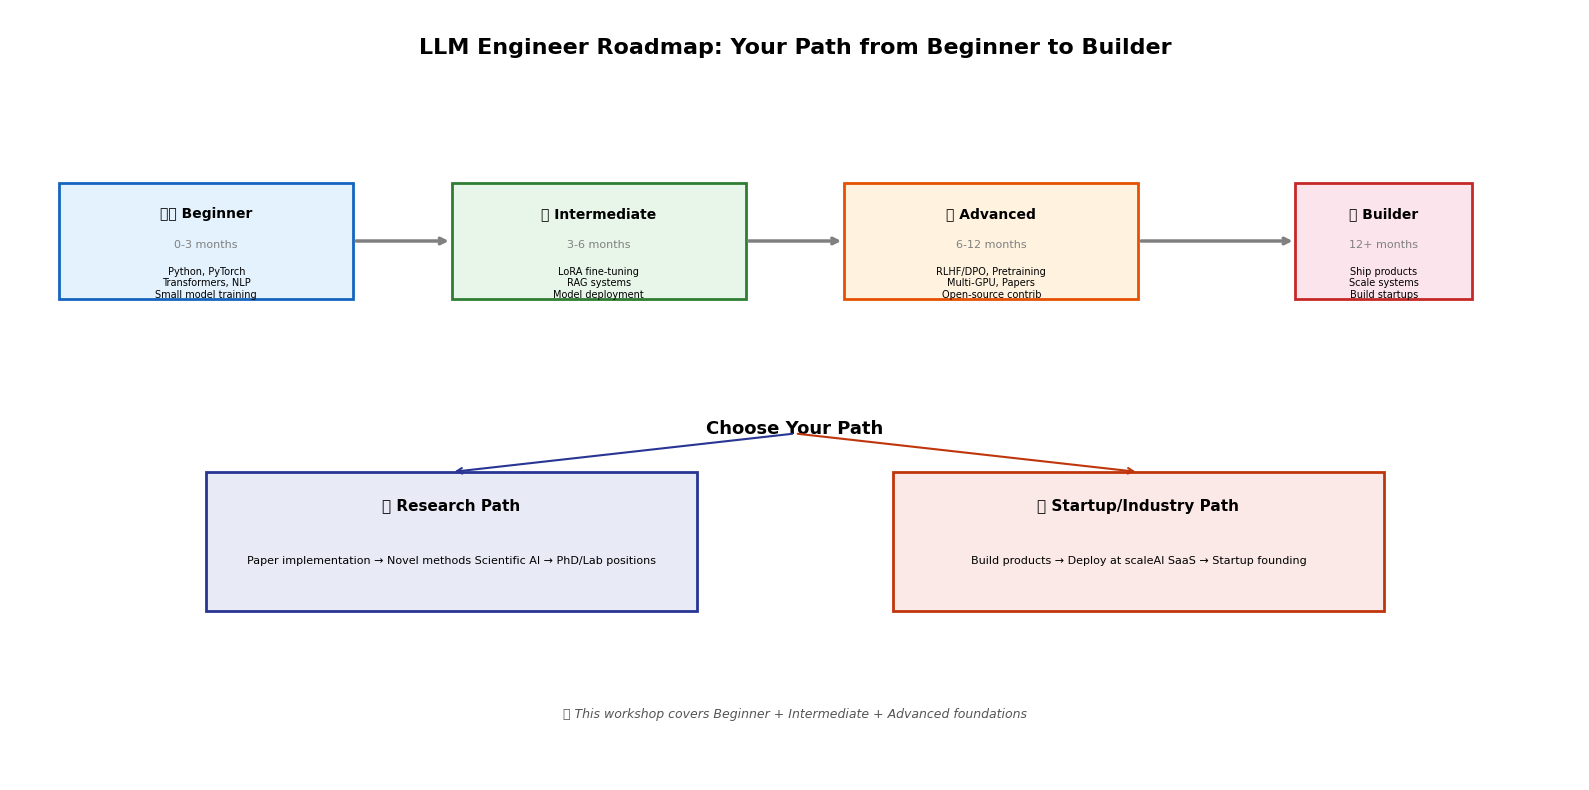

Your roadmap is ready! Choose your path and start building.


In [9]:
# ============================================================
# Interactive Roadmap Visualization
# ============================================================

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

fig, ax = plt.subplots(figsize=(16, 8))
ax.set_xlim(0, 16)
ax.set_ylim(0, 10)
ax.axis('off')

# Title
ax.text(8, 9.5, 'LLM Engineer Roadmap: Your Path from Beginner to Builder',
        ha='center', va='center', fontsize=16, fontweight='bold')

# Stages
stages = [
    {"x": 2, "y": 7, "w": 3, "h": 1.5, "color": "#E3F2FD", "border": "#1565C0",
     "title": "🧑‍🎓 Beginner", "time": "0-3 months",
     "skills": "Python, PyTorch\nTransformers, NLP\nSmall model training"},
    
    {"x": 6, "y": 7, "w": 3, "h": 1.5, "color": "#E8F5E9", "border": "#2E7D32",
     "title": "🧠 Intermediate", "time": "3-6 months",
     "skills": "LoRA fine-tuning\nRAG systems\nModel deployment"},
    
    {"x": 10, "y": 7, "w": 3, "h": 1.5, "color": "#FFF3E0", "border": "#E65100",
     "title": "🔬 Advanced", "time": "6-12 months",
     "skills": "RLHF/DPO, Pretraining\nMulti-GPU, Papers\nOpen-source contrib"},
    
    {"x": 14, "y": 7, "w": 1.8, "h": 1.5, "color": "#FCE4EC", "border": "#C62828",
     "title": "🚀 Builder", "time": "12+ months",
     "skills": "Ship products\nScale systems\nBuild startups"},
]

for s in stages:
    rect = plt.Rectangle((s["x"] - s["w"]/2, s["y"] - s["h"]/2), 
                         s["w"], s["h"], facecolor=s["color"], 
                         edgecolor=s["border"], linewidth=2, zorder=2)
    ax.add_patch(rect)
    ax.text(s["x"], s["y"] + 0.35, s["title"], ha='center', va='center',
            fontsize=10, fontweight='bold', zorder=3)
    ax.text(s["x"], s["y"] - 0.05, s["time"], ha='center', va='center',
            fontsize=8, color='gray', zorder=3)
    ax.text(s["x"], s["y"] - 0.55, s["skills"], ha='center', va='center',
            fontsize=7, zorder=3)

# Arrows between stages
for i in range(len(stages) - 1):
    x1 = stages[i]["x"] + stages[i]["w"]/2
    x2 = stages[i+1]["x"] - stages[i+1]["w"]/2
    ax.annotate('', xy=(x2, 7), xytext=(x1, 7),
               arrowprops=dict(arrowstyle='->', color='gray', lw=2.5))

# Two paths at the bottom
ax.text(8, 4.5, 'Choose Your Path', ha='center', fontsize=13, fontweight='bold')

# Research path
rect_r = plt.Rectangle((2, 2.2), 5, 1.8, facecolor='#E8EAF6', 
                        edgecolor='#283593', linewidth=2, zorder=2)
ax.add_patch(rect_r)
ax.text(4.5, 3.5, '🔬 Research Path', ha='center', fontsize=11, fontweight='bold')
ax.text(4.5, 2.8, 'Paper implementation → Novel methods Scientific AI → PhD/Lab positions', ha='center', fontsize=8)

# Industry path
rect_i = plt.Rectangle((9, 2.2), 5, 1.8, facecolor='#FBE9E7', 
                        edgecolor='#BF360C', linewidth=2, zorder=2)
ax.add_patch(rect_i)
ax.text(11.5, 3.5, '🚀 Startup/Industry Path', ha='center', fontsize=11, fontweight='bold')
ax.text(11.5, 2.8, 'Build products → Deploy at scaleAI SaaS → Startup founding', ha='center', fontsize=8)

# Arrows from Builder to paths
ax.annotate('', xy=(4.5, 4.0), xytext=(8, 4.5),
           arrowprops=dict(arrowstyle='->', color='#283593', lw=1.5))
ax.annotate('', xy=(11.5, 4.0), xytext=(8, 4.5),
           arrowprops=dict(arrowstyle='->', color='#BF360C', lw=1.5))

# This workshop marker
ax.text(8, 0.8, '📘 This workshop covers Beginner + Intermediate + Advanced foundations',
        ha='center', fontsize=9, style='italic', color='#555')

plt.tight_layout()
plt.savefig('roadmap.png', dpi=120, bbox_inches='tight', facecolor='white')
plt.show()
print("Your roadmap is ready! Choose your path and start building.")


---
# Section 7: Curated Open-Source Resources

## 📦 Codebases & Libraries

| Tool | What It Does | Link |
|------|-------------|------|
| **HuggingFace Transformers** | Load, train, fine-tune any model | github.com/huggingface/transformers |
| **HuggingFace TRL** | SFT, RLHF, DPO training | github.com/huggingface/trl |
| **HuggingFace PEFT** | LoRA, QLoRA, Adapters | github.com/huggingface/peft |
| **LLaMA Factory** | One-click fine-tuning for 100+ models | github.com/hiyouga/LLaMA-Factory |
| **Axolotl** | Advanced fine-tuning framework | github.com/axolotl-ai-cloud/axolotl |
| **LangChain** | Build LLM applications, chains, agents | github.com/langchain-ai/langchain |
| **LlamaIndex** | Data framework for RAG | github.com/run-llama/llama_index |
| **vLLM** | High-throughput LLM serving | github.com/vllm-project/vllm |
| **Ollama** | Run LLMs locally (one command) | github.com/ollama/ollama |
| **llama.cpp** | CPU inference for LLMs | github.com/ggerganov/llama.cpp |
| **DeepSpeed** | Distributed training | github.com/microsoft/DeepSpeed |
| **ChromaDB** | Open-source vector database | github.com/chroma-core/chroma |
| **FAISS** | Fast similarity search (Meta) | github.com/facebookresearch/faiss |

## 📊 Datasets

| Dataset | Type | Size | Use For |
|---------|------|------|---------|
| **The Pile** | Pretraining | 800GB | Pretraining experiments |
| **RedPajama** | Pretraining | 1.2T tokens | Open reproduction of LLaMA data |
| **OpenAssistant (OASST)** | Instructions | 160K conversations | SFT training |
| **Alpaca** | Instructions | 52K examples | SFT training |
| **Dolly** | Instructions | 15K examples | SFT training |
| **UltraFeedback** | Preferences | 64K comparisons | RLHF/DPO training |
| **HH-RLHF** | Preferences | 170K comparisons | RLHF training |
| **SlimOrca** | Instructions | 500K examples | High-quality SFT |
| **ShareGPT** | Conversations | 90K conversations | Multi-turn SFT |

## 📘 Books

| Book | Focus | Level |
|------|-------|-------|
| **Build a Large Language Model from Scratch** (Raschka) | Full LLM implementation | Intermediate |
| **Deep Learning** (Goodfellow, Bengio, Courville) | DL theory foundations | Advanced |
| **Natural Language Processing with Transformers** (Tunstall et al.) | Practical NLP with HuggingFace | Intermediate |
| **Designing Machine Learning Systems** (Huyen) | MLOps and production | Intermediate |
| **Speech and Language Processing** (Jurafsky & Martin) | NLP theory | Advanced |

## 📄 Must-Read Papers

### Foundational
| Paper | Year | Key Contribution |
|-------|------|-----------------|
| **Attention Is All You Need** (Vaswani et al.) | 2017 | Introduced the Transformer |
| **BERT** (Devlin et al.) | 2018 | Bidirectional pretraining |
| **Language Models are Few-Shot Learners** (GPT-3) | 2020 | Scaling + in-context learning |
| **Scaling Laws for Neural Language Models** (Kaplan et al.) | 2020 | How performance scales with compute |

### Alignment & Fine-Tuning
| Paper | Year | Key Contribution |
|-------|------|-----------------|
| **InstructGPT / Training LMs to Follow Instructions with Human Feedback** | 2022 | RLHF pipeline |
| **LoRA: Low-Rank Adaptation of Large Language Models** (Hu et al.) | 2021 | Parameter-efficient fine-tuning |
| **Direct Preference Optimization (DPO)** (Rafailov et al.) | 2023 | RLHF without reward model |
| **Constitutional AI** (Bai et al.) | 2022 | AI self-alignment |

### RAG & Augmentation
| Paper | Year | Key Contribution |
|-------|------|-----------------|
| **Retrieval-Augmented Generation for Knowledge-Intensive Tasks** (Lewis et al.) | 2020 | RAG concept |
| **Self-RAG** (Asai et al.) | 2023 | Self-reflective RAG |
| **Toolformer** (Schick et al.) | 2023 | LLMs that learn to use tools |

### Architecture
| Paper | Year | Key Contribution |
|-------|------|-----------------|
| **LLaMA** (Touvron et al.) | 2023 | Efficient open-source LLM |
| **Mistral / Mixtral** (Jiang et al.) | 2023 | Mixture of Experts architecture |
| **FlashAttention** (Dao et al.) | 2022 | IO-aware exact attention |
| **RoPE** (Su et al.) | 2021 | Rotary position embeddings |

## 🎓 Free Courses

| Course | Provider | Topics |
|--------|----------|--------|
| **Stanford CS224N** | Stanford (YouTube) | NLP with Deep Learning |
| **Andrej Karpathy's Neural Nets: Zero to Hero** | YouTube | Build GPT from scratch |
| **HuggingFace NLP Course** | HuggingFace | Practical Transformers |
| **Full Stack LLM Bootcamp** | FSDL | Building LLM applications |
| **LLM University** | Cohere | LLM fundamentals to advanced |


---
# Section 8: Mini Practical Demos

Three hands-on code snippets that bridge our workshop to production tools.

---

## 8.1 LoRA Fine-Tuning with HuggingFace (Conceptual)


In [10]:
# ============================================================
# PRACTICAL 1: LoRA Fine-Tuning (HuggingFace PEFT style)
# ============================================================
# This is a CONCEPTUAL snippet showing the real-world workflow.
# You'd need: pip install transformers peft trl datasets bitsandbytes
# And a GPU with enough memory for the base model.

LORA_FINETUNE_CODE = '''
# === Step 1: Load base model in 4-bit (QLoRA) ===
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
import torch

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
)

model_name = "meta-llama/Meta-Llama-3.1-8B"
model = AutoModelForCausalLM.from_pretrained(
    model_name, quantization_config=bnb_config, device_map="auto"
)
tokenizer = AutoTokenizer.from_pretrained(model_name)

# === Step 2: Apply LoRA ===
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training

model = prepare_model_for_kbit_training(model)

lora_config = LoraConfig(
    r=16,                        # LoRA rank
    lora_alpha=32,               # Scaling factor
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj"],  # Which layers
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
)

model = get_peft_model(model, lora_config)
model.print_trainable_parameters()
# Output: "trainable params: 6,553,600 || all params: 8,036,098,048 || trainable%: 0.0816"

# === Step 3: Prepare dataset (Alpaca format) ===
from datasets import load_dataset

dataset = load_dataset("tatsu-lab/alpaca", split="train[:1000]")

def format_instruction(example):
    return {
        "text": f"### Instruction:\n{example['instruction']}\n\n"
                f"### Response:\n{example['output']}"
    }

dataset = dataset.map(format_instruction)

# === Step 4: Train with SFTTrainer ===
from trl import SFTTrainer, SFTConfig

training_args = SFTConfig(
    output_dir="./lora_output",
    num_train_epochs=3,
    per_device_train_batch_size=4,
    gradient_accumulation_steps=4,
    learning_rate=2e-4,
    logging_steps=10,
    save_steps=100,
    fp16=True,
    max_seq_length=512,
)

trainer = SFTTrainer(
    model=model,
    train_dataset=dataset,
    args=training_args,
    tokenizer=tokenizer,
)

trainer.train()

# === Step 5: Save and merge ===
model.save_pretrained("./lora_adapter")
# To merge LoRA weights back into base model:
# merged = model.merge_and_unload()
# merged.save_pretrained("./merged_model")
'''

print("LoRA Fine-Tuning Workflow (Production Code)")
print("=" * 55)
print(LORA_FINETUNE_CODE)
print()
print("To run this, you need:")
print("  • pip install transformers peft trl datasets bitsandbytes")
print("  • A GPU with 12+ GB VRAM (for QLoRA with 8B model)")
print("  • Or use Google Colab T4 (free tier)")


LoRA Fine-Tuning Workflow (Production Code)

# === Step 1: Load base model in 4-bit (QLoRA) ===
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
import torch

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
)

model_name = "meta-llama/Meta-Llama-3.1-8B"
model = AutoModelForCausalLM.from_pretrained(
    model_name, quantization_config=bnb_config, device_map="auto"
)
tokenizer = AutoTokenizer.from_pretrained(model_name)

# === Step 2: Apply LoRA ===
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training

model = prepare_model_for_kbit_training(model)

lora_config = LoraConfig(
    r=16,                        # LoRA rank
    lora_alpha=32,               # Scaling factor
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj"],  # Which layers
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
)

model = get_peft_model(model, lora_config

## 8.2 Simple RAG Pipeline (Production-Style)

In [11]:
# ============================================================
# PRACTICAL 2: RAG Pipeline (Production-ready conceptual code)
# ============================================================

RAG_CODE = '''
# === Step 1: Install dependencies ===
# pip install langchain chromadb sentence-transformers

# === Step 2: Load and chunk documents ===
from langchain.text_splitter import RecursiveCharacterTextSplitter
from langchain_community.document_loaders import TextLoader

loader = TextLoader("your_document.txt")
documents = loader.load()

splitter = RecursiveCharacterTextSplitter(
    chunk_size=500,          # Characters per chunk
    chunk_overlap=50,        # Overlap between chunks
    separators=["\n\n", "\n", ". ", " "]
)
chunks = splitter.split_documents(documents)
print(f"Created {len(chunks)} chunks")

# === Step 3: Create vector store ===
from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain_community.vectorstores import Chroma

embeddings = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2"
)

vectorstore = Chroma.from_documents(
    documents=chunks,
    embedding=embeddings,
    persist_directory="./chroma_db"
)

# === Step 4: Build retrieval chain ===
retriever = vectorstore.as_retriever(
    search_type="similarity",
    search_kwargs={"k": 3}     # Return top 3 chunks
)

# === Step 5: Query with LLM ===
from langchain_community.llms import Ollama
from langchain.chains import RetrievalQA

llm = Ollama(model="llama3.1:8b")

qa_chain = RetrievalQA.from_chain_type(
    llm=llm,
    chain_type="stuff",         # Stuff all docs into prompt
    retriever=retriever,
    return_source_documents=True
)

# Ask a question
result = qa_chain.invoke({"query": "What is the main topic of the document?"})
print(result["result"])
print("Sources:", [doc.metadata for doc in result["source_documents"]])
'''

print("RAG Pipeline Workflow (Production Code)")
print("=" * 55)
print(RAG_CODE)
print()
print("To run this, you need:")
print("  • pip install langchain chromadb sentence-transformers")
print("  • Ollama installed locally (ollama.com)")
print("  • A text file to index")


RAG Pipeline Workflow (Production Code)

# === Step 1: Install dependencies ===
# pip install langchain chromadb sentence-transformers

# === Step 2: Load and chunk documents ===
from langchain.text_splitter import RecursiveCharacterTextSplitter
from langchain_community.document_loaders import TextLoader

loader = TextLoader("your_document.txt")
documents = loader.load()

splitter = RecursiveCharacterTextSplitter(
    chunk_size=500,          # Characters per chunk
    chunk_overlap=50,        # Overlap between chunks
    separators=["

", "
", ". ", " "]
)
chunks = splitter.split_documents(documents)
print(f"Created {len(chunks)} chunks")

# === Step 3: Create vector store ===
from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain_community.vectorstores import Chroma

embeddings = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2"
)

vectorstore = Chroma.from_documents(
    documents=chunks,
    embedding=embeddings,
    persist_dir

## 8.3 Basic Agent with Tool Use

In [13]:
# ============================================================
# PRACTICAL 3: Agent with Tool Use (Production-style)
# ============================================================

AGENT_CODE = '''
# === Using LangChain Agents ===
# pip install langchain langchain-community

from langchain.agents import Tool, AgentExecutor, create_react_agent
from langchain_community.llms import Ollama
from langchain import hub

llm = Ollama(model="llama3.1:8b")

# Define tools
def calculator(expression: str) -> str:
    """Safely evaluate a math expression."""
    try:
        # Use a safe evaluator in production (not eval!)
        import ast
        result = eval(compile(ast.parse(expression, mode='eval'), '<calc>', 'eval'))
        return str(result)
    except Exception as e:
        return f"Error: {e}"

def web_search(query: str) -> str:
    """Search the web for information."""
    # In production, use SerpAPI, Google Search API, or Brave Search
    return f"Search results for: {query}"

tools = [
    Tool(name="Calculator", func=calculator, 
         description="Useful for math calculations. Input: math expression"),
    Tool(name="Search", func=web_search,
         description="Useful for finding current information. Input: search query"),
]

# Create ReAct agent
prompt = hub.pull("hwchase17/react")  # Standard ReAct prompt
agent = create_react_agent(llm, tools, prompt)
agent_executor = AgentExecutor(agent=agent, tools=tools, verbose=True)

# Run
result = agent_executor.invoke({"input": "What is 1024 * 768?"})
print(result["output"])
'''

print("Agent with Tool Use (Production Code)")
print("=" * 55)
print(AGENT_CODE)
print()
print("To run this, you need:")
print("  • pip install langchain langchain-community langchainhub")
print("  • Ollama running locally")


Agent with Tool Use (Production Code)

# === Using LangChain Agents ===
# pip install langchain langchain-community

from langchain.agents import Tool, AgentExecutor, create_react_agent
from langchain_community.llms import Ollama
from langchain import hub

llm = Ollama(model="llama3.1:8b")

# Define tools
def calculator(expression: str) -> str:
    """Safely evaluate a math expression."""
    try:
        # Use a safe evaluator in production (not eval!)
        import ast
        result = eval(compile(ast.parse(expression, mode='eval'), '<calc>', 'eval'))
        return str(result)
    except Exception as e:
        return f"Error: {e}"

def web_search(query: str) -> str:
    """Search the web for information."""
    # In production, use SerpAPI, Google Search API, or Brave Search
    return f"Search results for: {query}"

tools = [
    Tool(name="Calculator", func=calculator, 
         description="Useful for math calculations. Input: math expression"),
    Tool(name="Search", func=we

## 8.4 Bonus: DPO Implementation from Scratch

Since DPO is the most important alternative to PPO-based RLHF, here's a working implementation you can study.


In [14]:
# ============================================================
# DPO (Direct Preference Optimization) from Scratch
# ============================================================
# DPO eliminates the reward model entirely - it optimizes 
# the policy directly from preference pairs.

import torch
import torch.nn as nn
import torch.nn.functional as F

def compute_dpo_loss(
    policy_model,
    reference_model,
    chosen_ids,        # [B, T] - preferred response tokens
    rejected_ids,      # [B, T] - rejected response tokens
    beta=0.1           # KL constraint strength
):
    '''
    Compute the DPO loss.
    
    DPO Loss = -log σ(β * (log π_θ(y_w|x)/π_ref(y_w|x) - log π_θ(y_l|x)/π_ref(y_l|x)))
    
    Where:
        y_w = preferred (chosen) response
        y_l = rejected response
        π_θ = policy model
        π_ref = frozen reference model
        β = temperature/constraint strength
    
    Args:
        policy_model: The model being optimized
        reference_model: Frozen reference model (SFT checkpoint)
        chosen_ids: Token IDs for preferred responses
        rejected_ids: Token IDs for rejected responses
        beta: Controls how much policy can deviate from reference
    
    Returns:
        loss: DPO loss (scalar)
        metrics: dict with useful training metrics
    '''
    
    def get_log_probs(model, input_ids):
        '''Get per-token log probabilities.'''
        logits, _ = model(input_ids[:, :-1])  # [B, T-1, V]
        log_probs = F.log_softmax(logits, dim=-1)
        
        # Gather log probs for actual tokens
        target_ids = input_ids[:, 1:]  # Shifted targets
        token_log_probs = log_probs.gather(2, target_ids.unsqueeze(-1)).squeeze(-1)
        
        # Sum log probs over sequence (sequence-level log probability)
        return token_log_probs.sum(dim=-1)  # [B]
    
    # Policy log probs
    policy_chosen_logp = get_log_probs(policy_model, chosen_ids)
    policy_rejected_logp = get_log_probs(policy_model, rejected_ids)
    
    # Reference log probs (no gradient)
    with torch.no_grad():
        ref_chosen_logp = get_log_probs(reference_model, chosen_ids)
        ref_rejected_logp = get_log_probs(reference_model, rejected_ids)
    
    # Log ratios
    chosen_log_ratio = policy_chosen_logp - ref_chosen_logp    # log(π_θ(y_w)/π_ref(y_w))
    rejected_log_ratio = policy_rejected_logp - ref_rejected_logp  # log(π_θ(y_l)/π_ref(y_l))
    
    # DPO loss: -log σ(β * (chosen_log_ratio - rejected_log_ratio))
    logits = beta * (chosen_log_ratio - rejected_log_ratio)
    loss = -F.logsigmoid(logits).mean()
    
    # Metrics
    with torch.no_grad():
        chosen_reward = beta * chosen_log_ratio
        rejected_reward = beta * rejected_log_ratio
        reward_accuracy = (chosen_reward > rejected_reward).float().mean()
        reward_margin = (chosen_reward - rejected_reward).mean()
    
    metrics = {
        "loss": loss.item(),
        "accuracy": reward_accuracy.item(),
        "reward_margin": reward_margin.item(),
        "chosen_reward": chosen_reward.mean().item(),
        "rejected_reward": rejected_reward.mean().item(),
    }
    
    return loss, metrics


# ============================================================
# Demo: Verify DPO loss computation
# ============================================================

# Create tiny models for demonstration
class TinyModel(nn.Module):
    def __init__(self, vocab_size=50, emb_dim=32):
        super().__init__()
        self.emb = nn.Embedding(vocab_size, emb_dim)
        self.head = nn.Linear(emb_dim, vocab_size)
        self.head.weight = self.emb.weight  # Weight tying
    def forward(self, ids, targets=None):
        return self.head(self.emb(ids)), None

policy = TinyModel()
reference = TinyModel()
reference.load_state_dict(policy.state_dict())
for p in reference.parameters():
    p.requires_grad = False

# Simulated preference data
chosen = torch.randint(0, 50, (4, 20))
rejected = torch.randint(0, 50, (4, 20))

# Compute DPO loss
loss, metrics = compute_dpo_loss(policy, reference, chosen, rejected, beta=0.1)

print("DPO Loss Computation Demo")
print("=" * 50)
print(f"Loss:            {metrics['loss']:.4f}")
print(f"Accuracy:        {metrics['accuracy']:.1%}")
print(f"Reward margin:   {metrics['reward_margin']:.4f}")
print(f"Chosen reward:   {metrics['chosen_reward']:.4f}")
print(f"Rejected reward: {metrics['rejected_reward']:.4f}")
print()
print("At initialization (policy = reference), loss ≈ log(2) = 0.693")
print(f"Our loss: {metrics['loss']:.4f} (close to log(2) = {torch.tensor(2.0).log().item():.4f}) ✓")
print()
print("DPO advantages over PPO:")
print("  • No separate reward model needed")
print("  • Simpler - single training stage")
print("  • More stable training")
print("  • Lower memory (2 models instead of 3)")


DPO Loss Computation Demo
Loss:            0.6931
Accuracy:        0.0%
Reward margin:   0.0000
Chosen reward:   0.0000
Rejected reward: 0.0000

At initialization (policy = reference), loss ≈ log(2) = 0.693
Our loss: 0.6931 (close to log(2) = 0.6931) ✓

DPO advantages over PPO:
  • No separate reward model needed
  • Simpler - single training stage
  • More stable training
  • Lower memory (2 models instead of 3)


---
# 🎉 Workshop Complete!

## What You've Accomplished

Over **8 notebooks**, you have:

| Notebook | Skill Gained |
|----------|-------------|
| NB 1 | Built BPE tokenizer from scratch |
| NB 2 | Implemented multi-head causal attention |
| NB 3 | Assembled a complete GPT architecture |
| NB 4 | Pretrained an LLM with next-token prediction |
| NB 5 | Applied SFT with loss masking |
| NB 6 | Implemented RLHF (Reward Model + PPO) |
| NB 7 | Built a chat system comparing all 3 stages |
| NB 8 | Explored the modern LLM stack and planned your future path |

## Your Next Steps

1. **This week:** Run all notebooks end-to-end on your machine
2. **This month:** Pick one production tool (LoRA/RAG/Agents) and build a project
3. **This quarter:** Fine-tune a real open-source model on domain-specific data
4. **This year:** Ship an AI product or publish research

## Remember

> *"The best way to understand LLMs is to build them. The best way to master them is to ship products with them."*

The field moves fast - but your foundations are now solid. Everything new is built on top of what you've learned here: attention, transformers, pretraining, alignment.

**Go build something amazing.** 🚀

---

*Workshop by Unisole Empower - Building LLMs from Scratch*
*Based on "Build a Large Language Model from Scratch" by Sebastian Raschka*
